# Exercise 4: Hate Speech Classification using Multinomial Naive Bayes

Instructions:
- You do not need to split your data. Use the training, validation and test sets provided below.
- Use Multinomial Naive Bayes to train a model that can classify if a sentence is a hate speech or non-hate speech
- A sentence with a label of zero (0) is classified as non-hate speech
- A sentence with a label of one (1) is classified as a hate speech

Apply text pre-processing techniques such as
- Converting to lowercase
- Stop word Removal
- Removal of digits, special characters
- Stemming or Lemmatization but not both
- Count Vectorizer or TF-IDF Vectorizer but not both

Evaluate your model by:
- Providing input by yourself
- Creating a Confusion Matrix
- Calculating the Accuracy, Precision, Recall and F1-Score

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [28]:
train_url = "hf://datasets/mapsoriano/2016_2022_hate_speech_filipino/train"

In [35]:
display(df_train.head())

,text,label
0,Presidential candidate Mar Roxas implies that ...,1
1,Parang may mali na sumunod ang patalastas ng N...,1
2,Bet ko. Pula Ang Kulay Ng Posas,1
3,[USERNAME] kakampink,0
4,Bakit parang tahimik ang mga PINK about Doc Wi...,1


In [29]:
val_url = "hf://datasets/mapsoriano/2016_2022_hate_speech_filipino/validation"

In [36]:
display(df_validation.head())

,text,label
0,VinTee [USERNAME] [USERNAME] and [USERNAME] Ka...,1
1,binay's sidekicks were employees of makati cit...,1
2,This is expected as we use different methodol...,0
3,Ang tanga tanga talaga ni Nancy Binay eh. Tskkk.,1
4,Binay giving away bracelets after every selfie...,0


In [30]:
test_url = "hf://datasets/mapsoriano/2016_2022_hate_speech_filipino/test"

In [37]:
display(df_test.head())

,text,label
0,Binay: Patuloy ang kahirapan dahil sa maling p...,0
1,SA GOBYERNONG TAPAT WELCOME SA BAGUO ANG LAHAT...,0
2,wait so ur telling me Let Leni Lead mo pero NY...,1
3,[USERNAME]wish this is just a nightmare that ...,0
4,doc willie ong and isko sabunutan po,0


In [33]:
data = pd.concat([df_train, df_validation, df_test])
print(data.head())
print(data.info())

                                                text  label
0  Presidential candidate Mar Roxas implies that ...      1
1  Parang may mali na sumunod ang patalastas ng N...      1
2                    Bet ko. Pula Ang Kulay Ng Posas      1
3                               [USERNAME] kakampink      0
4  Bakit parang tahimik ang mga PINK about Doc Wi...      1
<class 'pandas.core.frame.DataFrame'>
Index: 27383 entries, 0 to 2809
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    27383 non-null  object
 1   label   27383 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 641.8+ KB
None


**Training Set**

Use this to train your model

In [18]:
df_train = dataset["train"].to_pandas()

In [19]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21773 entries, 0 to 21772
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    21773 non-null  object
 1   label   21773 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 340.3+ KB


In [41]:
!pip install datasets

In [43]:
from datasets import load_dataset

dataset = load_dataset("mapsoriano/2016_2022_hate_speech_filipino")

df_train = dataset["train"].to_pandas()
df_validation = dataset["validation"].to_pandas()
df_test = dataset["test"].to_pandas()

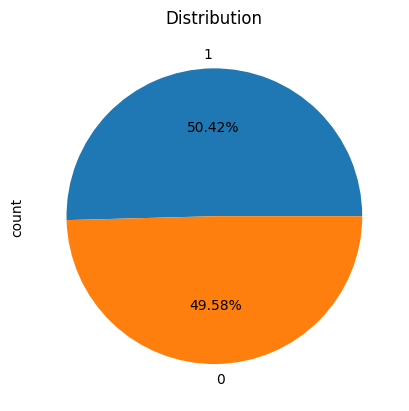

In [47]:
count = data['label'].value_counts()
count.plot(kind='pie', autopct='%1.2f%%')
plt.title('Distribution')
plt.show()

In [23]:
df_validation = dataset["validation"].to_pandas()

In [25]:
df_test = dataset["test"].to_pandas()

In [48]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [52]:
def clean_text(text):
    text = re.sub("[^A-Za-z]", " ", str(text))
    text = text.lower()
    text = text.split()
    stemmer = PorterStemmer()
    text = [stemmer.stem(word) for word in text if word not in set(stopwords.words("english"))]
    return " ".join(text)


data['clean_text'] = data['text'].apply(clean_text)

In [53]:
X = data['clean_text'].values
y = data['label'].values

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [55]:
vect_tfidf = TfidfVectorizer(stop_words='english', max_df=0.5)

In [56]:
X_train_tfidf = vect_tfidf.fit_transform(X_train)

In [57]:
X_test_tfidf = vect_tfidf.transform(X_test)

In [58]:
vect_count = CountVectorizer(stop_words='english', max_df=0.5)
X_train_count = vect_count.fit_transform(X_train)
X_test_count = vect_count.transform(X_test)

In [59]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [60]:
y_pred_tfidf = nb.predict(X_test_tfidf)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf) * 100
print("TF-IDF Accuracy:", acc_tfidf)
print(confusion_matrix(y_test, y_pred_tfidf))

TF-IDF Accuracy: 83.14059646987218
[[3207  867]
 [ 518 3623]]


In [61]:
nb2 = MultinomialNB()
nb2.fit(X_train_count, y_train)
y_pred_count = nb2.predict(X_test_count)
acc_count = accuracy_score(y_test, y_pred_count) * 100
print("CountVectorizer Accuracy:", acc_count)
print(confusion_matrix(y_test, y_pred_count))

CountVectorizer Accuracy: 82.95800365185636
[[3160  914]
 [ 486 3655]]


In [62]:
new_text = pd.Series(["Bobo ka! wala kang kwenta!"])
new_text_clean = new_text.apply(clean_text)
new_text_vec = vect_tfidf.transform(new_text_clean)
print("Prediction:", nb.predict(new_text_vec))

Prediction: [1]


In [63]:
new_text2 = pd.Series(["Magandang araw kaibigan, kumusta ka?"])
new_text_clean2 = new_text2.apply(clean_text)
new_text_vec2 = vect_tfidf.transform(new_text_clean2)
print("Prediction:", nb.predict(new_text_vec2))

Prediction: [1]
